Dataset loaded successfully!

Sample text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hun

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 167s 129ms/step - accuracy: 0.0463 - loss: 6.6757 - val_accuracy: 0.0703 - val_loss: 6.4882
Epoch 2/5
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 157s 123ms/step - accuracy: 0.0837 - loss: 6.0294 - val_accuracy: 0.0806 - val_loss: 6.4213
Epoch 3/5
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 167s 131ms/step - accuracy: 0.0981 - loss: 5.7037 - val_accuracy: 0.0847 - val_loss: 6.4496
Epoch 4/5
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 169s 132ms/step - accuracy: 0.1094 - loss: 5.4345 - val_accuracy: 0.0854 - val_loss: 6.5097
Epoch 5/5
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 170s 133ms/step - accuracy: 0.1208 - loss: 5.1939 - val_accuracy: 0.0834 - val_loss: 6.5861

================ RESULTS ================

Training Loss      : 5.093548774719238
Training Accuracy  : 0.13130991160869598
Validation Loss    : 6.586080074310303
Validation Accuracy: 0.08335375040769577


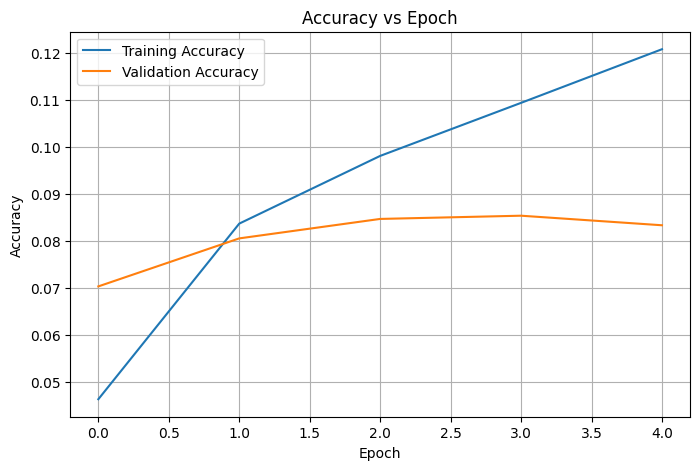

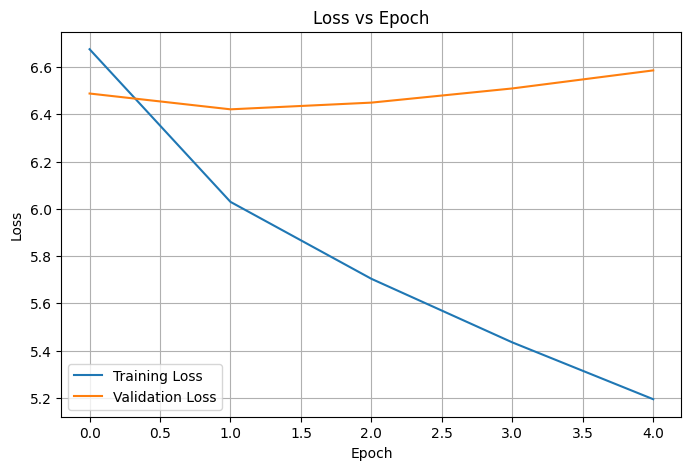


================ GENERATED TEXT ================


Seed 1: the king
Generated: the king henry vi king richard iii what is the matter to the king and i will be revenged to the tower

Seed 2: love is
Generated: love is thy hand and so far as thou art thou art thou art thou art thou art thou art thou art

Seed 3: my lord
Generated: my lord king richard iii what is the matter to the king and i will be revenged to the tower and let

Seed 4: what shall
Generated: what shall be so much as you shall be a king and he is not so much as i am a king

Seed 5: good night
Generated: good night ' and thou art thou art thou art thou art thou art thou art thou art thou art thou art

Model saved successfully!


In [3]:
# ============================================================
# EXPERIMENT NO. 5
# IMPLEMENTATION OF A RECURRENT NEURAL NETWORK (RNN)
# FOR TEXT GENERATION
# ============================================================

# ------------------------------------------------------------
# PART A: DATASET PREPARATION
# ------------------------------------------------------------

# Install required libraries if needed
!pip install -q datasets tensorflow matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ------------------------------------------------------------
# 1. LOAD TINY SHAKESPEARE DATASET
# ------------------------------------------------------------

# Download the tiny shakespeare dataset directly
filepath = tf.keras.utils.get_file(
    'tinyshakespeare.txt',
    'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
)

with open(filepath, 'r') as f:
    text = f.read()

print("Dataset loaded successfully!")

print("\nSample text:")
print(text[:1000])

print("\nTotal characters:", len(text))

# ------------------------------------------------------------
# 2. CONVERT TEXT TO LOWERCASE
# ------------------------------------------------------------

text = text.lower()

print("\nLowercase sample:")
print(text[:500])

# ------------------------------------------------------------
# 3. TOKENIZATION
# ------------------------------------------------------------

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("\nVocabulary size:", total_words)

# Convert words into integer sequences
word_sequences = tokenizer.texts_to_sequences([text])[0]

print("\nFirst 30 tokenized words:")
print(word_sequences[:30])

# ------------------------------------------------------------
# 4. GENERATE INPUT SEQUENCES
# ------------------------------------------------------------

sequence_length = 20

input_sequences = []

for i in range(sequence_length, len(word_sequences)):
    sequence = word_sequences[i-sequence_length:i+1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

print("\nInput sequence shape:", input_sequences.shape)

# Separate input and target
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

# ------------------------------------------------------------
# 5. TRAINING AND VALIDATION SPLIT
# ------------------------------------------------------------

split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))

# ------------------------------------------------------------
# PART B: IMPLEMENTING THE RNN MODEL
# ------------------------------------------------------------

# ------------------------------------------------------------
# 6. CREATE RNN MODEL
# ------------------------------------------------------------

model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=128,
        input_length=sequence_length
    ),

    SimpleRNN(
        128,
        return_sequences=False
    ),

    Dense(
        total_words,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# 7. COMPILE MODEL
# ------------------------------------------------------------

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# 8. DISPLAY MODEL SUMMARY
# ------------------------------------------------------------

print("\n================ MODEL SUMMARY ================\n")
model.summary()

# ------------------------------------------------------------
# PART C: TRAINING AND EVALUATION
# ------------------------------------------------------------

# ------------------------------------------------------------
# 9. TRAIN THE RNN
# ------------------------------------------------------------

epochs = 5
batch_size = 128

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)

# ------------------------------------------------------------
# 10. FINAL TRAINING AND VALIDATION RESULTS
# ------------------------------------------------------------

train_loss, train_accuracy = model.evaluate(
    X_train,
    y_train,
    verbose=0
)

val_loss, val_accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("\n================ RESULTS ================\n")

print("Training Loss      :", train_loss)
print("Training Accuracy  :", train_accuracy)

print("Validation Loss    :", val_loss)
print("Validation Accuracy:", val_accuracy)

# ------------------------------------------------------------
# 11. ACCURACY VS EPOCH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 12. LOSS VS EPOCH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# PART D: TEXT GENERATION
# ------------------------------------------------------------

# ------------------------------------------------------------
# 13. FUNCTION TO GENERATE TEXT
# ------------------------------------------------------------

index_word = {
    value: key
    for key, value in tokenizer.word_index.items()
}

def generate_text(seed_text, next_words=20):

    seed_text = seed_text.lower()

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = token_list[-sequence_length:]

        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        predicted_probs = model.predict(
            token_list,
            verbose=0
        )[0]

        predicted_id = np.argmax(predicted_probs)

        predicted_word = index_word.get(
            predicted_id,
            ""
        )

        if predicted_word == "":
            break

        seed_text += " " + predicted_word

    return seed_text


# ------------------------------------------------------------
# 14. GENERATE TEXT USING DIFFERENT SEED INPUTS
# ------------------------------------------------------------

seed1 = "the king"
seed2 = "love is"
seed3 = "my lord"
seed4 = "what shall"
seed5 = "good night"

print("\n================ GENERATED TEXT ================\n")

print("\nSeed 1:", seed1)
print("Generated:", generate_text(seed1, 20))

print("\nSeed 2:", seed2)
print("Generated:", generate_text(seed2, 20))

print("\nSeed 3:", seed3)
print("Generated:", generate_text(seed3, 20))

print("\nSeed 4:", seed4)
print("Generated:", generate_text(seed4, 20))

print("\nSeed 5:", seed5)
print("Generated:", generate_text(seed5, 20))


# ------------------------------------------------------------
# 15. SAVE MODEL
# ------------------------------------------------------------

model.save("rnn_text_generation_model.keras")

print("\nModel saved successfully!")

# ============================================================
# END OF EXPERIMENT
# ============================================================
